# TFM – Clasificación de tipos tumorales a partir de datos de expresión génica

## T2. Obtención de los datos, control de calidad (QC) y análisis exploratorio (PCA/UMAP)

**Autora:** Ona Sánchez Núñez

**Dataset:** *Gene expression cancer RNA-Seq* (Fiorini, 2016), UCI Machine Learning Repository ([doi:10.24432/C5R88H](https://doi.org/10.24432/C5R88H)), licencia CC BY 4.0. Es una extracción aleatoria del dataset TCGA Pan-Cancer (Weinstein et al., 2013).

La primera ejecución descarga los CSV originales (~70 MB) en la carpeta `Dataset/UCI`. Las figuras se muestran en el notebook y también se guardan en la carpeta `figuras/`.

**Requisitos:** numpy, pandas, scikit-learn, scipy, matplotlib, umap-learn.

### Librerías y configuración

In [1]:
import io
import tarfile
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import umap

%matplotlib inline

SEED = 42
BASE = Path.cwd()  # carpeta donde está el notebook
DATA_DIR = BASE / "Dataset" / "UCI"
FIG_DIR = BASE / "figuras"
FIG_DIR.mkdir(exist_ok=True)
URL = "https://archive.ics.uci.edu/static/public/401/gene+expression+cancer+rna+seq.zip"

# Un color fijo por tipo tumoral (el mismo en todas las figuras)
CLASES = ["BRCA", "COAD", "KIRC", "LUAD", "PRAD"]
NOMBRES = {"BRCA": "Mama (BRCA)", "COAD": "Colon (COAD)", "KIRC": "Riñón (KIRC)",
           "LUAD": "Pulmón (LUAD)", "PRAD": "Próstata (PRAD)"}
COLORES = {"BRCA": "#2a78d6", "COAD": "#eb6834", "KIRC": "#1baf7a", "LUAD": "#eda100", "PRAD": "#e87ba4"}
TINTA, TINTA2, REJILLA = "#1f1f1e", "#55554f", "#e6e5df"

plt.rcParams.update({
    "font.size": 10, "axes.edgecolor": "#b5b4ad", "axes.labelcolor": TINTA, "text.color": TINTA,
    "xtick.color": TINTA2, "ytick.color": TINTA2, "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})


def guardar(fig, nombre):
    """Guarda la figura en figuras/ y la muestra en el notebook."""
    fig.savefig(FIG_DIR / nombre, facecolor="white")
    plt.show()


def leyenda_clases(ax, extra=None, **kw):
    handles = [Line2D([], [], marker="o", ls="", ms=7, color=COLORES[c], label=NOMBRES[c]) for c in CLASES]
    ax.legend(handles=handles + (extra or []), frameon=False, **kw)

C:\Users\onasa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Obtención de los datos

In [2]:
carpeta = DATA_DIR / "TCGA-PANCAN-HiSeq-801x20531"
if not (carpeta / "data.csv").exists():
    print("Descargando el dataset de UCI...")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(URL) as r:
        zbytes = io.BytesIO(r.read())
    with zipfile.ZipFile(zbytes) as z:
        tgz = z.read("TCGA-PANCAN-HiSeq-801x20531.tar.gz")
    with tarfile.open(fileobj=io.BytesIO(tgz), mode="r:gz") as t:
        t.extractall(DATA_DIR)

X = pd.read_csv(carpeta / "data.csv", index_col=0)
etiquetas = pd.read_csv(carpeta / "labels.csv", index_col=0)["Class"]
print(f"data.csv:   {X.shape[0]} muestras x {X.shape[1]} genes")
print(f"labels.csv: {etiquetas.shape[0]} etiquetas")
X.iloc[:5, :6]

data.csv:   801 muestras x 20531 genes
labels.csv: 801 etiquetas


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0


**Resultado:** se usan los CSV originales de UCI y no la copia en Excel (`Dataset/Datos.xlsx`), que está truncada (riesgo R4 de la PEC1). Las dimensiones coinciden con las que indica UCI: 801 muestras y 20.531 genes.

## 2. Control de calidad (QC)

### 2.1 Correspondencia, valores faltantes, duplicados y escala

In [3]:
# Correspondencia entre muestras y etiquetas
mismo_orden = X.index.equals(etiquetas.index)
print(f"Mismas muestras y en el mismo orden en data y labels: {mismo_orden}")
assert mismo_orden, "Las muestras de data.csv y labels.csv no coinciden"
y = etiquetas.loc[X.index]

# Valores faltantes, tipos y duplicados
var_gen = X.var()
print(f"Valores faltantes: {int(X.isna().sum().sum())}")
print(f"Columnas no numéricas: {int((~X.dtypes.apply(pd.api.types.is_numeric_dtype)).sum())}")
print(f"Muestras duplicadas: {int(X.duplicated().sum())}")
print(f"Genes duplicados (columnas idénticas): {int(X.T.duplicated().sum())}, "
      f"de los cuales entre genes con varianza > 0: {int(X.loc[:, var_gen > 0].T.duplicated().sum())}")

# Escala de los valores
valores = X.values.ravel()
print(f"\nRango de valores: {valores.min():.2f} – {valores.max():.2f}")
print(f"Media: {valores.mean():.2f} | Mediana: {np.median(valores):.2f}")
print(f"Porcentaje de ceros: {100 * (valores == 0).mean():.1f} %")

# Genes sin variación o poco informativos
genes_var0 = var_gen.index[var_gen == 0]
print(f"\nGenes con varianza 0: {len(genes_var0)} (todos con valor 0 en todas las muestras: "
      f"{bool((X[genes_var0] == 0).all().all())})")
print(f"Genes con expresión media < 1: {int((X.mean() < 1).sum())}")

Mismas muestras y en el mismo orden en data y labels: True


Valores faltantes: 0
Columnas no numéricas: 0


Muestras duplicadas: 0


Genes duplicados (columnas idénticas): 266, de los cuales entre genes con varianza > 0: 0

Rango de valores: 0.00 – 20.78


Media: 6.44 | Mediana: 7.61
Porcentaje de ceros: 14.2 %

Genes con varianza 0: 267 (todos con valor 0 en todas las muestras: True)
Genes con expresión media < 1: 3123


**Resultado:**
- Los datos están limpios: no hay valores faltantes ni muestras duplicadas, y las muestras de `data.csv` y `labels.csv` coinciden y están en el mismo orden.
- Aparecen 266 genes "duplicados", pero son genes con valor 0 en todas las muestras (forman parte de los 267 genes con varianza 0). Entre los genes con variación no hay duplicados. Los 267 genes con varianza 0 no aportan información y se eliminarán en la pipeline con `VarianceThreshold`, dentro de cada partición.
- Los valores van de 0 a 20,78: son datos RNA-seq ya transformados con log2, así que no hace falta volver a aplicar el logaritmo (se ve mejor en el histograma del apartado 2.2).
- 3.123 genes tienen una expresión media < 1, es decir, casi no se expresan.

### 2.2 QC por muestra

In [4]:
X_ok = X.drop(columns=genes_var0)
qc = pd.DataFrame({
    "clase": y,
    "pct_ceros": 100 * (X_ok == 0).mean(axis=1),
    "media": X_ok.mean(axis=1),
})

# Correlación de cada muestra con el perfil mediano de su clase (2.000 genes más variables)
top = X_ok.var().nlargest(2000).index
perfiles = X_ok[top].groupby(y).median()
qc["corr_clase"] = [np.corrcoef(X_ok.loc[s, top], perfiles.loc[y[s]])[0, 1] for s in X_ok.index]


# Muestras atípicas: muy alejadas del resto de su clase (criterio robusto: mediana - 3,5 MAD)
def atipicas_robustas(serie):
    med = serie.median()
    mad = (serie - med).abs().median() * 1.4826
    return serie < med - 3.5 * mad


qc["atipica"] = qc.groupby("clase")["corr_clase"].transform(atipicas_robustas)

resumen = qc.groupby("clase").agg(pct_ceros=("pct_ceros", "median"), media=("media", "median"),
                                  corr_mediana=("corr_clase", "median"), corr_minima=("corr_clase", "min"),
                                  atipicas=("atipica", "sum"))
print(f"Muestras atípicas a revisar: {int(qc['atipica'].sum())} ({100 * qc['atipica'].mean():.1f} %)")
resumen.round(3)

Muestras atípicas a revisar: 35 (4.4 %)


,pct_ceros,media,corr_mediana,corr_minima,atipicas
clase,,,,,
BRCA,12.984,6.522,0.831,0.535,7
COAD,14.351,6.367,0.882,0.653,1
KIRC,12.954,6.565,0.906,0.453,16
LUAD,12.643,6.627,0.830,0.487,7
PRAD,12.426,6.563,0.907,0.677,4


In [5]:
# Muestras que los modelos clasificaron mal en la prueba preliminar de la T3
# (validación cruzada con regresión logística, SVM, Random Forest y XGBoost)
MAL_CLASIFICADAS = ["sample_61", "sample_129", "sample_507", "sample_599"]
qc.loc[MAL_CLASIFICADAS, ["clase", "corr_clase", "atipica"]].round(3)

,clase,corr_clase,atipica
sample_61,KIRC,0.453,True
sample_129,LUAD,0.609,True
sample_507,LUAD,0.598,True
sample_599,LUAD,0.487,True


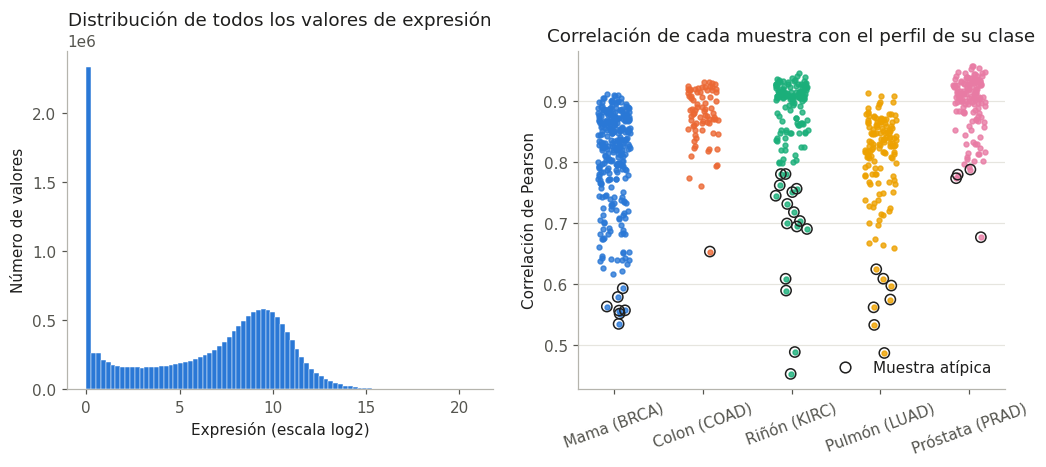

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].hist(valores, bins=80, color="#2a78d6", edgecolor="white", linewidth=0.3)
axs[0].set(title="Distribución de todos los valores de expresión", xlabel="Expresión (escala log2)",
           ylabel="Número de valores")
axs[0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

qc["x"] = qc["clase"].map({c: i for i, c in enumerate(CLASES)}) + \
    np.random.default_rng(SEED).uniform(-0.18, 0.18, len(qc))
for c in CLASES:
    v = qc[qc.clase == c]
    axs[1].scatter(v.x, v.corr_clase, s=10, color=COLORES[c], alpha=0.8, zorder=3)
o = qc[qc.atipica]
axs[1].scatter(o.x, o.corr_clase, s=45, facecolor="none", edgecolor=TINTA, lw=1, zorder=4)
axs[1].set_xticks(range(5), [NOMBRES[c] for c in CLASES], rotation=20)
axs[1].set(title="Correlación de cada muestra con el perfil de su clase", ylabel="Correlación de Pearson")
axs[1].grid(axis="y", color=REJILLA, zorder=0)
axs[1].legend(handles=[Line2D([], [], marker="o", ls="", ms=7, mfc="none", mec=TINTA, label="Muestra atípica")],
              frameon=False, loc="lower right")
guardar(fig, "fig1_qc.png")

**Resultado:**
- El histograma tiene la forma típica de datos RNA-seq en escala log2: un pico en 0 (un 14,2 % de los valores, genes no expresados) y el resto concentrado entre 5 y 13 aproximadamente, con la moda en torno a 9–10.
- El porcentaje de ceros (~12–14 %) y la expresión media (~6,4–6,6) son muy parecidos en todas las clases, así que no hay muestras con problemas técnicos evidentes.
- Las muestras se parecen bastante al perfil de su clase (correlación mediana entre 0,83 y 0,91). BRCA y LUAD son las clases más heterogéneas, y KIRC y PRAD, las más homogéneas.
- El criterio robusto marca 35 muestras atípicas (4,4 %), casi la mitad en KIRC (16). La mayoría de las de KIRC tienen correlaciones de 0,69–0,78, que solo parecen bajas porque la clase es muy homogénea.
- Las 4 muestras que los modelos clasificaron mal en la prueba preliminar están entre las atípicas, con correlaciones de 0,45–0,61. Esto indica que los errores se deben a muestras poco típicas de su clase, no a un fallo de los modelos. No se eliminan, porque no hay ninguna razón técnica para hacerlo, pero se tendrán en cuenta en el análisis de errores.

## 3. Análisis exploratorio

### 3.1 Distribución de clases

Ratio clase mayor / clase menor: 3.8


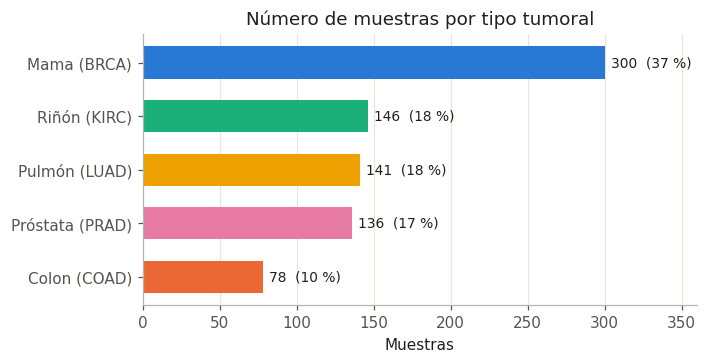

In [7]:
conteo = y.value_counts().reindex(CLASES)
print(f"Ratio clase mayor / clase menor: {conteo.max() / conteo.min():.1f}")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
orden = conteo.sort_values()
ax.barh([NOMBRES[c] for c in orden.index], orden.values, color=[COLORES[c] for c in orden.index], height=0.6)
for i, n in enumerate(orden.values):
    ax.text(n + 4, i, f"{n}  ({100 * n / len(y):.0f} %)", va="center", fontsize=9, color=TINTA)
ax.set(title="Número de muestras por tipo tumoral", xlabel="Muestras", xlim=(0, orden.max() * 1.2))
ax.grid(axis="x", color=REJILLA, zorder=0)
ax.set_axisbelow(True)
guardar(fig, "fig2_clases.png")

**Resultado:** las clases están desequilibradas. BRCA tiene 300 muestras (37,5 %) y COAD solo 78 (9,7 %), casi 4 veces menos. Por eso en la validación se usarán particiones estratificadas, la métrica F1 macro (da el mismo peso a cada clase) y `class_weight='balanced'`. Un modelo que predijera siempre BRCA ya acertaría el 37,5 %, que es la referencia mínima que hay que superar.

### 3.2 PCA

El PCA y el UMAP se ajustan con todos los datos porque aquí solo sirven para visualizar. No se usan para evaluar modelos, así que no hay riesgo de *data leakage*.

Varianza explicada: PC1 10.5 %, PC2 8.8 %, PC1+PC2 19.3 %, 10 PCs 46.6 %, 50 PCs 63.7 %
Silhouette en las 10 primeras PCs: 0.328


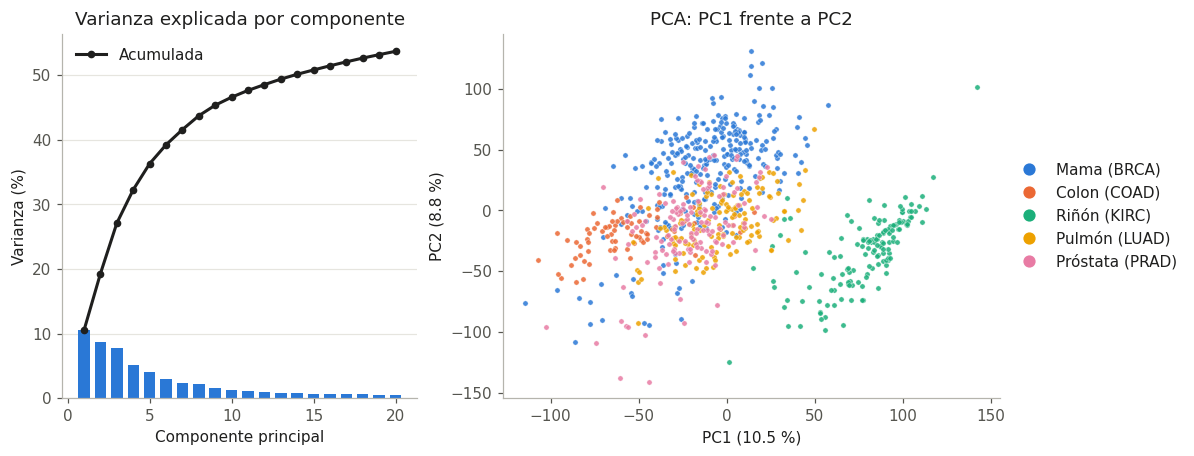

In [8]:
Xz = StandardScaler().fit_transform(X_ok)
pca = PCA(n_components=50, random_state=SEED)
Z = pca.fit_transform(Xz)
var_exp = pca.explained_variance_ratio_
print(f"Varianza explicada: PC1 {100 * var_exp[0]:.1f} %, PC2 {100 * var_exp[1]:.1f} %, "
      f"PC1+PC2 {100 * var_exp[:2].sum():.1f} %, 10 PCs {100 * var_exp[:10].sum():.1f} %, "
      f"50 PCs {100 * var_exp.sum():.1f} %")
sil_pca = silhouette_score(Z[:, :10], y)
print(f"Silhouette en las 10 primeras PCs: {sil_pca:.3f}")

fig, axs = plt.subplots(1, 2, figsize=(11, 4.3), gridspec_kw={"width_ratios": [1, 1.4]})
k = np.arange(1, 21)
axs[0].bar(k, 100 * var_exp[:20], color="#2a78d6", width=0.7)
axs[0].plot(k, 100 * np.cumsum(var_exp[:20]), color=TINTA, lw=2, marker="o", ms=4, label="Acumulada")
axs[0].set(title="Varianza explicada por componente", xlabel="Componente principal", ylabel="Varianza (%)")
axs[0].legend(frameon=False)
axs[0].grid(axis="y", color=REJILLA, zorder=0)
axs[0].set_axisbelow(True)
for c in CLASES:
    m = (y == c).values
    axs[1].scatter(Z[m, 0], Z[m, 1], s=12, color=COLORES[c], alpha=0.85, edgecolor="white", linewidth=0.3)
axs[1].set(title="PCA: PC1 frente a PC2", xlabel=f"PC1 ({100 * var_exp[0]:.1f} %)",
           ylabel=f"PC2 ({100 * var_exp[1]:.1f} %)")
leyenda_clases(axs[1], loc="center left", bbox_to_anchor=(1, 0.5))
guardar(fig, "fig3_pca.png")

**Resultado:**
- La varianza está muy repartida: PC1 y PC2 explican juntas solo un 19,3 % de la variabilidad, hacen falta 10 componentes para llegar al 46,6 % y con 50 solo se llega al 63,7 %. Es lo esperable con más de 20.000 genes: la información no se concentra en pocas direcciones.
- En el plano PC1–PC2, KIRC (riñón) se separa claramente del resto a lo largo de PC1, BRCA (mama) ocupa la parte superior y COAD (colon), la izquierda. En cambio, LUAD (pulmón) y PRAD (próstata) se solapan entre sí y con BRCA en el centro del gráfico.
- El coeficiente silhouette en las 10 primeras PCs es 0,33, lo que indica una separación moderada. Por lo tanto, dos o tres componentes no bastan para distinguir todas las clases, pero los modelos sí lo consiguen al combinar muchos genes a la vez.

### 3.3 UMAP

Se calcula sobre las 50 primeras PCs, una práctica habitual para reducir ruido y tiempo de cálculo.

C:\Users\onasa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette en el espacio UMAP: 0.748


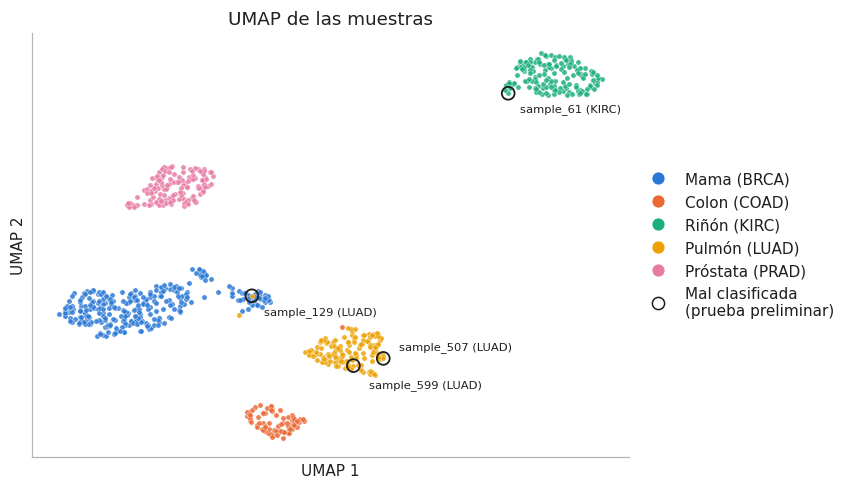

In [9]:
emb = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=SEED).fit_transform(Z)
sil_umap = silhouette_score(emb, y)
print(f"Silhouette en el espacio UMAP: {sil_umap:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
for c in CLASES:
    m = (y == c).values
    ax.scatter(emb[m, 0], emb[m, 1], s=12, color=COLORES[c], alpha=0.85, edgecolor="white", linewidth=0.3)
# Se marcan las muestras mal clasificadas en la prueba preliminar
desplaz = {"sample_61": (8, -12), "sample_129": (8, -12), "sample_507": (10, 6), "sample_599": (10, -14)}
for s in MAL_CLASIFICADAS:
    i = X.index.get_loc(s)
    ax.scatter(emb[i, 0], emb[i, 1], s=70, facecolor="none", edgecolor=TINTA, lw=1.2, zorder=4)
    ax.annotate(f"{s} ({y[s]})", (emb[i, 0], emb[i, 1]), xytext=desplaz[s], textcoords="offset points",
                fontsize=7.5, color=TINTA)
ax.set(title="UMAP de las muestras", xlabel="UMAP 1", ylabel="UMAP 2", xticks=[], yticks=[])
leyenda_clases(ax, extra=[Line2D([], [], marker="o", ls="", ms=8, mfc="none", mec=TINTA,
                                 label="Mal clasificada\n(prueba preliminar)")],
               loc="center left", bbox_to_anchor=(1, 0.5))
guardar(fig, "fig4_umap.png")

**Resultado:**
- El UMAP muestra cinco grupos claramente separados, uno por tipo tumoral (silhouette 0,75, frente a 0,33 en la PCA). Esto confirma que la estructura de clases existe, aunque en la PCA no se viera del todo porque es un método lineal y solo se representan dos direcciones.
- BRCA (mama) aparece dividido en dos subgrupos. Podrían corresponder a subtipos moleculares del cáncer de mama, pero como no hay información clínica de las muestras no se puede comprobar.
- De las muestras mal clasificadas, `sample_129` (LUAD) cae dentro del subgrupo pequeño de BRCA: su perfil se parece más al de mama que al de pulmón, lo que explica que casi todos los modelos la confundan. `sample_61` (KIRC) y `sample_507` (LUAD) quedan en el borde de su propio grupo, y `sample_599` (LUAD), dentro. En estas tres la confusión no se aprecia en el UMAP, pero sí en su baja correlación con el perfil de su clase (apartado 2.2), así que son casos frontera.
- UMAP solo se usa para explorar: las distancias entre grupos no tienen una interpretación directa y no sirve como prueba del rendimiento de los modelos.

### 3.4 Heatmap de los 500 genes más variables

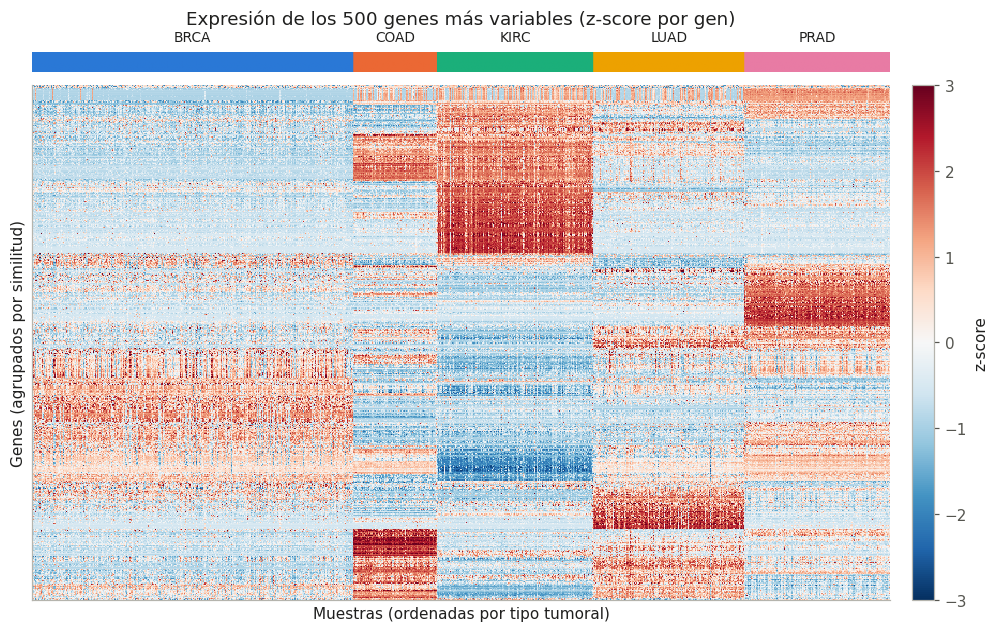

In [10]:
top500 = X_ok.var().nlargest(500).index
orden_muestras = y.sort_values(kind="stable").index
H = X_ok.loc[orden_muestras, top500]
H = (H - H.mean()) / H.std()  # z-score por gen
orden_genes = leaves_list(linkage(H.T.values, method="average", metric="correlation"))
H = H.iloc[:, orden_genes].clip(-3, 3)

fig = plt.figure(figsize=(10, 6))
ax_c = fig.add_axes([0.08, 0.90, 0.78, 0.03])
ax_h = fig.add_axes([0.08, 0.10, 0.78, 0.78])
ax_b = fig.add_axes([0.88, 0.10, 0.02, 0.78])
ax_c.imshow([[matplotlib.colors.to_rgb(COLORES[c]) for c in y[orden_muestras]]], aspect="auto")
ax_c.set_axis_off()
ax_c.set_title("Expresión de los 500 genes más variables (z-score por gen)", pad=18)
clases_ord = y[orden_muestras].values
for c in CLASES:
    ax_c.text(np.where(clases_ord == c)[0].mean(), -0.9, c, ha="center", va="bottom", fontsize=9)
im = ax_h.imshow(H.T.values, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3, interpolation="nearest")
ax_h.set(xlabel="Muestras (ordenadas por tipo tumoral)", ylabel="Genes (agrupados por similitud)",
         xticks=[], yticks=[])
fig.colorbar(im, cax=ax_b, label="z-score")
guardar(fig, "fig5_heatmap.png")

**Resultado:**
- Cada tipo tumoral tiene bloques de genes propios muy expresados solo en esa clase (bandas rojas). Los más marcados son los de KIRC, COAD y PRAD. KIRC tiene además un bloque de genes claramente menos expresados que en el resto (banda azul).
- LUAD también tiene su propio bloque, y BRCA se distingue sobre todo por un grupo amplio de genes moderadamente elevados. En estas dos clases los patrones son menos nítidos, lo que coincide con que sean las más heterogéneas en el QC.
- Estos patrones son la base de la clasificación y, más adelante, del análisis de explicabilidad (OE4). Como los genes están anonimizados (`gene_X`), no se puede interpretar su función biológica (riesgo R5).

## 4. Resumen

In [11]:
atip_mal = qc.loc[MAL_CLASIFICADAS, "atipica"].sum()
print(f"{X.shape[0]} muestras, {X.shape[1]} genes ({len(genes_var0)} con varianza 0), 5 clases.")
print(f"Sin valores faltantes ni duplicados. Datos en escala log2 (0 – {valores.max():.2f}).")
print(f"Clases desequilibradas (ratio {conteo.max() / conteo.min():.1f}).")
print(f"Separación de clases: silhouette {sil_pca:.2f} (PCA, 10 PCs) y {sil_umap:.2f} (UMAP).")
print(f"{int(qc['atipica'].sum())} muestras atípicas a revisar; {atip_mal} de las "
      f"{len(MAL_CLASIFICADAS)} mal clasificadas en la prueba preliminar están entre ellas.")

801 muestras, 20531 genes (267 con varianza 0), 5 clases.
Sin valores faltantes ni duplicados. Datos en escala log2 (0 – 20.78).
Clases desequilibradas (ratio 3.8).
Separación de clases: silhouette 0.33 (PCA, 10 PCs) y 0.75 (UMAP).
35 muestras atípicas a revisar; 4 de las 4 mal clasificadas en la prueba preliminar están entre ellas.


**Conclusión de la T2:** los datos tienen buena calidad y no hace falta eliminar muestras. Solo hay que quitar los genes sin variación, cosa que se hará dentro de la pipeline. Las clases están desequilibradas, lo que justifica la validación estratificada y el uso del F1 macro. Los cinco tipos tumorales tienen perfiles de expresión claramente diferentes, por lo que es esperable que los modelos obtengan un rendimiento muy alto (riesgo R6). Los pocos errores se concentran en muestras poco típicas de su clase, sobre todo de LUAD, que los modelos confunden con BRCA.